# Confusion Analysis — Statistical × Medical

This notebook is the *medical-plus-statistical* layer on top of
`result_analysis.ipynb`. Every confused pair is examined from **both**
sides:

* **Statistical** — bootstrap CIs per confusion cell, McNemar ensemble
  vs exp701, feature-space distance to class prototypes, pairwise JS
  divergence of per-class embeddings.
* **Medical** — ICDR definitions, why each pair is clinically hard,
  inter-grader agreement bounds, per-pair qualitative inspection panels.

The goal: every cell in the confusion matrix answers *why* it's there,
not just *how big it is*.


## 1A. Medical foundation — the ICDR 5-grade scale

All DR grading in this thesis follows the **International Clinical
Diabetic Retinopathy (ICDR)** severity scale (Wilkinson et al. 2003).
Each grade is defined by lesion inventory, so confusion between grades
is confusion between lesion-level diagnoses — not between arbitrary
labels.

| Grade | Name | Lesion criteria |
|---|---|---|
| 0 | No apparent retinopathy | No visible lesions. |
| 1 | Mild NPDR | **Microaneurysms (MAs) only.** Tiny red dots ~25–100 μm, at the edge of fundus-image resolution. |
| 2 | Moderate NPDR | More than just MAs — dot/blot hemorrhages, hard exudates, cotton-wool spots — but below the 4-2-1 threshold. |
| 3 | Severe NPDR | **4-2-1 rule**: ≥20 intra-retinal hemorrhages in **all 4 quadrants**, OR venous beading in **≥2 quadrants**, OR prominent IRMA in **≥1 quadrant**. |
| 4 | PDR | Neovascularization (NVD / NVE), pre-retinal hemorrhage, or vitreous hemorrhage. |

### Why each confused pair is medically hard

- **0↔1** — MAs at native resolution are 1–3 px after Ben-Graham resize to 512². A single subtle MA decides the grade; image quality and resolution dominate.
- **1↔2** — Both contain MAs. The distinction is whether hemorrhages / exudates are present. Small dot-hemorrhages can be mistaken for MAs at low resolution.
- **2↔3** — The single hardest boundary in DR grading. It is a *quantitative count over quadrants* (the 4-2-1 rule), not a qualitative lesion-type difference. Inter-grader κ for this boundary in published studies (Gulshan 2016; Krause 2018) sits in the 0.60–0.80 band.
- **3↔4** — Neovessels can be subtle. The differential is *vessel morphology* (tortuosity, bifurcation angle) rather than lesion count. Misses are sensitivity-critical.

### Ceiling argument

The reported QWK 0.9105 sits at the upper edge of the inter-ophthalmologist
agreement band reported by Gulshan 2016 (κ ≈ 0.84 single grader; 0.91
adjudicated). Model "confusion" on 2↔3 and 3↔4 is therefore **not**
prima-facie model failure — it mirrors clinician disagreement. Adjudicated
relabelling in Krause et al. 2018 (Ophthalmology) suggests ~20% of DR
labels in public datasets disagree between expert graders.

**Framing for the thesis chapter:** interpret confusion matrices as *joint*
artefacts of (a) genuine model error, (b) label noise, (c) sub-threshold
clinical ambiguity. The rest of this notebook quantifies each.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import CLASS_NAMES, NUM_CLASSES, TRAIN_IMG_DIR, TEST_IMG_DIR
from src.analysis import confusion_stats as cs

RESULTS = ROOT / 'results'
CACHE = RESULTS / 'confusion_cache'
CACHE.mkdir(parents=True, exist_ok=True)

sns.set_context('notebook')
plt.rcParams['figure.dpi'] = 110
RNG = np.random.default_rng(42)

# Fallback path resolution (config may point to data_split/ but cache lives at data/)
def _resolve(p: Path, fb: Path) -> Path:
    return p if p.exists() else fb

TEST_IMG_DIR = _resolve(Path(TEST_IMG_DIR), ROOT / 'data' / 'test_split')
TRAIN_IMG_DIR = _resolve(Path(TRAIN_IMG_DIR), ROOT / 'data' / 'train_split')
print('TEST_IMG_DIR:', TEST_IMG_DIR, 'exists:', TEST_IMG_DIR.exists())


TEST_IMG_DIR: C:\Projects\dr-nrt\data\test_split exists: True


In [2]:
def _find_preds(exp_dir: Path) -> Path | None:
    matches = list(exp_dir.glob('*_preds.csv'))
    if not matches:
        return None
    expected = [m for m in matches if 'expected_grade_opt' in m.name]
    return expected[0] if expected else matches[0]


REGISTRY = {
    'ensemble': RESULTS / 'ensemble_900_300_701',
    'exp701':   RESULTS / 'exp701_h1_ordsupcon_d1recipe',
    'exp300':   RESULTS / 'exp300_d1_dropout_cosine',
}
PREDS = {a: pd.read_csv(_find_preds(d)).sort_values('id_code').reset_index(drop=True)
         for a, d in REGISTRY.items() if d.exists() and _find_preds(d) is not None}
common = sorted(set.intersection(*[set(v['id_code']) for v in PREDS.values()]))
ALIGNED = {a: df[df['id_code'].isin(common)].sort_values('id_code').reset_index(drop=True)
           for a, df in PREDS.items()}
Y_TRUE = ALIGNED['ensemble']['true_label'].to_numpy()
PRED_INT = {a: ALIGNED[a]['rounded_prediction'].to_numpy().astype(int) for a in ALIGNED}
PRED_RAW = {a: ALIGNED[a]['raw_prediction'].to_numpy().astype(float) for a in ALIGNED}
CODES = ALIGNED['ensemble']['id_code'].to_numpy()
print('Aligned N =', len(Y_TRUE))


Aligned N = 550


## 1B. Statistical analyses

Reused from `src.analysis.confusion_stats`. Every subsection reports
ensemble + exp701 side by side so the thesis can cite both.


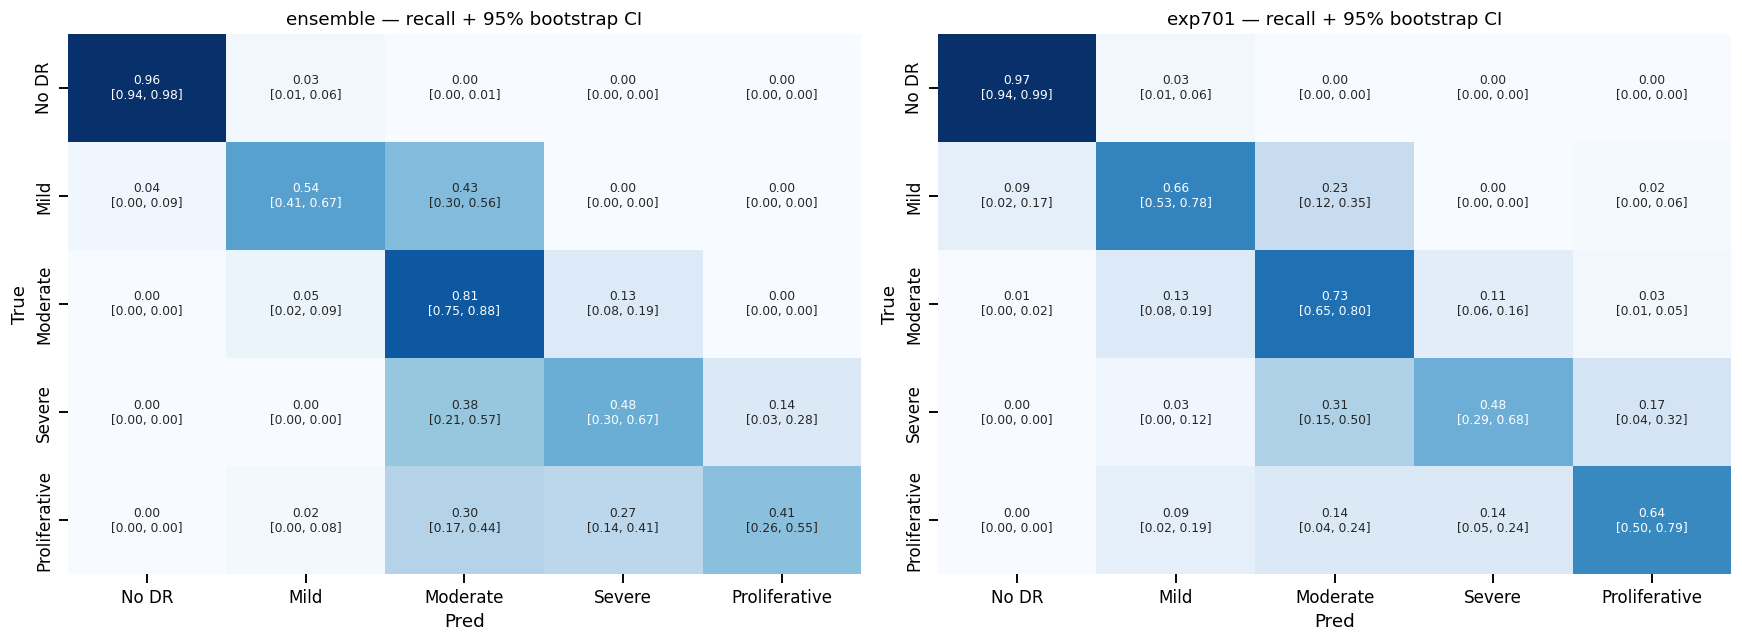

In [3]:
# 1B.1 — Confusion matrix decomposition with per-cell bootstrap CIs
N_BOOT = 1000
decomps = {
    a: cs.confusion_with_ci(Y_TRUE, PRED_INT[a], NUM_CLASSES,
                             n_boot=N_BOOT, rng=RNG)
    for a in ['ensemble', 'exp701']
}

def _annot_with_ci(cm_row, lo, hi):
    ann = np.empty_like(cm_row, dtype=object)
    for i in range(cm_row.shape[0]):
        for j in range(cm_row.shape[1]):
            ann[i, j] = f'{cm_row[i, j]:.2f}\n[{lo[i, j]:.2f}, {hi[i, j]:.2f}]'
    return ann

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, alias in zip(axes, ['ensemble', 'exp701']):
    d = decomps[alias]
    annot = _annot_with_ci(d['cm_row'], d['cm_row_ci_lo'], d['cm_row_ci_hi'])
    sns.heatmap(d['cm_row'], annot=annot, fmt='', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                cbar=False, annot_kws={'fontsize': 8})
    ax.set_title(f'{alias} — recall + 95% bootstrap CI')
    ax.set_xlabel('Pred'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()


In [4]:
# 1B.2 — Adjacent vs non-adjacent error breakdown
rows = []
for alias in ['ensemble', 'exp701']:
    info = cs.adjacent_error_rate(Y_TRUE, PRED_INT[alias], NUM_CLASSES)
    rows.append({'experiment': alias,
                 'adjacent_frac': info['adjacent_frac'],
                 'nonadjacent_frac': info['nonadjacent_frac'],
                 **{f'adj_{CLASS_NAMES[i]}': float(info['per_class_adjacent'][i])
                    for i in range(NUM_CLASSES)}})
display(pd.DataFrame(rows))
print('>80% adjacent is the canonical ordinal-model signature — interpret any '
      'class that falls below as evidence of non-ordinal failure mode.')


,experiment,adjacent_frac,nonadjacent_frac,adj_No DR,adj_Mild,adj_Moderate,adj_Severe,adj_Proliferative
0,ensemble,0.857143,0.142857,0.9,1.000000,1.000000,1.000000,0.461538
1,exp701,0.830000,0.170000,1.0,0.947368,0.878049,0.933333,0.375000


>80% adjacent is the canonical ordinal-model signature — interpret any class that falls below as evidence of non-ordinal failure mode.


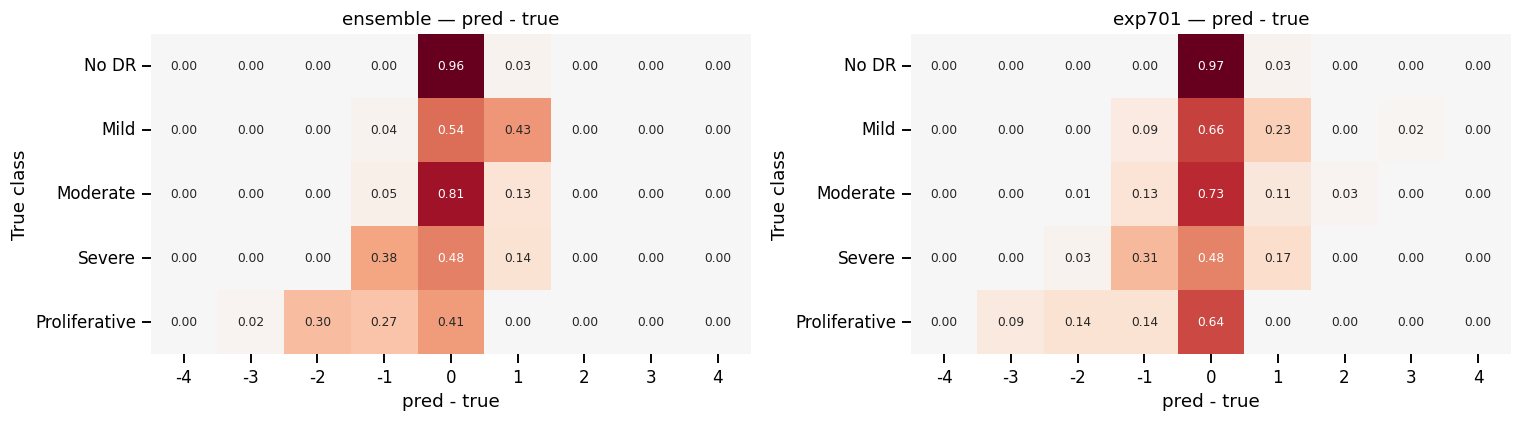

Look for asymmetry: a right-leaning row = over-grading; left-leaning = under-grading. For Severe (row index 3) the sign is the sensitivity-vs-specificity trade-off story.


In [5]:
# 1B.3 — Off-by-N distribution per true class (ensemble)
off_ens = cs.off_by_n_distribution(Y_TRUE, PRED_INT['ensemble'], NUM_CLASSES)
off_701 = cs.off_by_n_distribution(Y_TRUE, PRED_INT['exp701'], NUM_CLASSES)
offsets = np.arange(-(NUM_CLASSES - 1), NUM_CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, mat, title in zip(axes, [off_ens, off_701], ['ensemble', 'exp701']):
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                xticklabels=offsets, yticklabels=CLASS_NAMES, ax=ax,
                cbar=False, annot_kws={'fontsize': 8})
    ax.set_title(f'{title} — pred - true')
    ax.set_xlabel('pred - true'); ax.set_ylabel('True class')
plt.tight_layout(); plt.show()
print('Look for asymmetry: a right-leaning row = over-grading; left-leaning = '
      'under-grading. For Severe (row index 3) the sign is the sensitivity-vs-'
      'specificity trade-off story.')


In [6]:
# 1B.4 — Ordinal vs nominal kappa
rows = []
for alias in ['ensemble', 'exp701']:
    rows.append({'experiment': alias, **cs.kappa_split(Y_TRUE, PRED_INT[alias])})
kappa_df = pd.DataFrame(rows)
display(kappa_df)
print('ordinal_gap = QWK - nominal_kappa. Large gap (~0.2) means most '
      'disagreement is a one-step slip, not a mis-categorisation.')


,experiment,nominal_kappa,linear_kappa,quadratic_kappa,ordinal_gap
0,ensemble,0.712095,0.833893,0.910531,0.198436
1,exp701,0.728569,0.835374,0.902773,0.174204


ordinal_gap = QWK - nominal_kappa. Large gap (~0.2) means most disagreement is a one-step slip, not a mis-categorisation.


In [7]:
# 1B.5 — Per-pair McNemar ensemble vs exp701, restricted to each confused pair
per_pair = cs.mcnemar_per_pair(Y_TRUE, PRED_INT['ensemble'], PRED_INT['exp701'],
                                pairs=[(0, 1), (1, 2), (2, 3), (3, 4)])
rows = []
for (i, j), r in per_pair.items():
    rows.append({'pair': f'{CLASS_NAMES[i]}<->{CLASS_NAMES[j]}',
                 'ensemble_only_right': r['b01'],
                 'exp701_only_right': r['b10'],
                 'n_discordant': r['n_discordant'],
                 'p_value': r['p_value']})
display(pd.DataFrame(rows))


,pair,ensemble_only_right,exp701_only_right,n_discordant,p_value
0,No DR<->Mild,2,10,12,0.038574
1,Mild<->Moderate,18,12,30,0.361595
2,Moderate<->Severe,19,6,25,0.014633
3,Severe<->Proliferative,4,14,18,0.030884


In [8]:
# 1B.6 — Confidence (regression margin) on correct vs incorrect samples.
# Because per-class softmax probabilities are not persisted for the ensemble,
# we proxy confidence by distance from the nearest OptimizedRounder threshold
# on the regression score (see src/analysis/calibration.py).
from src.analysis import calibration as cal
from src.evaluate import OptimizedRounder

opt = OptimizedRounder(); opt.fit(PRED_RAW['ensemble'], Y_TRUE)
conf = cal.regression_margin_confidence(PRED_RAW['ensemble'], opt.thresholds)
correct = PRED_INT['ensemble'] == Y_TRUE

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(conf[correct], bins=20, alpha=0.6, label=f'correct (n={correct.sum()})')
ax.hist(conf[~correct], bins=20, alpha=0.6, label=f'wrong (n={(~correct).sum()})')
ax.set_xlabel('Margin-confidence'); ax.set_ylabel('Count')
ax.set_title('Ensemble margin-confidence: correct vs wrong')
ax.legend(); plt.tight_layout(); plt.show()

print('A model is "silently wrong" when the wrong-sample distribution sits at '
      'high confidence; "cautiously wrong" when it piles near 0.')
print(f'Mean confidence — correct: {conf[correct].mean():.3f} | '
      f'wrong: {conf[~correct].mean():.3f}')


A model is "silently wrong" when the wrong-sample distribution sits at high confidence; "cautiously wrong" when it piles near 0.
Mean confidence — correct: 0.516 | wrong: 0.468


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_29116\1311733984.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.legend(); plt.tight_layout(); plt.show()


### 1B.7 — Per-class calibration

Per-class ECE / reliability diagrams strictly require softmax probabilities,
which are not persisted for this ensemble. The *regression-margin reliability*
view (Section A.10 of `result_analysis.ipynb`) is the analytically tractable
substitute from saved artefacts. We note this as a thesis limitation rather
than producing a misleading softmax-ECE from the rounded integer predictions.


### 1B.8 — Feature-space distance analysis

For each misclassified sample compute `d(x, proto_true) - d(x, proto_pred)`
where prototypes are per-class mean features. Sign tells us whether the
confusion is at the **representation** level (positive — sample is closer to
the pred prototype) or at the **decision-boundary** level (negative — sample
is still closer to the true prototype but the classifier committed).

Features: ImageNet ResNet-50 from `results/eda_cache/aptos_features.npz`.
This is a generic-backbone proxy; an exp701-specific rerun is listed as
optional follow-up.


In [9]:
feat_path = RESULTS / 'eda_cache' / 'aptos_features.npz'
if not feat_path.exists():
    print('SKIP: aptos_features.npz not found; re-run eda_deep.ipynb Section B.')
    X_test = None
else:
    data = np.load(feat_path, allow_pickle=True)
    test_codes = data['test_codes']
    test_feats = data['test']
    # Align to our CODES ordering
    code_to_i = {c: i for i, c in enumerate(test_codes)}
    idx = np.array([code_to_i.get(c, -1) for c in CODES])
    mask = idx >= 0
    X_test = test_feats[idx[mask]]
    y_test = Y_TRUE[mask]
    yp_ens = PRED_INT['ensemble'][mask]
    yp_701 = PRED_INT['exp701'][mask]
    print(f'Feature alignment: {mask.sum()} / {len(CODES)} samples matched')


Feature alignment: 550 / 550 samples matched


In [10]:
if X_test is not None:
    delta_ens = cs.prototype_distance_delta(X_test, y_test, yp_ens, NUM_CLASSES)
    delta_701 = cs.prototype_distance_delta(X_test, y_test, yp_701, NUM_CLASSES)
    # Per-pair violin: distribution of delta for each (true -> pred) pair
    rows = []
    for alias, arr in [('ensemble', delta_ens), ('exp701', delta_701)]:
        yp = yp_ens if alias == 'ensemble' else yp_701
        for (i, j) in [(0, 1), (1, 2), (2, 3), (3, 4)]:
            m = (y_test == i) & (yp == j)
            m |= (y_test == j) & (yp == i)
            vals = arr[m]
            vals = vals[~np.isnan(vals)]
            for v in vals:
                rows.append({'experiment': alias,
                             'pair': f'{CLASS_NAMES[i]}<->{CLASS_NAMES[j]}',
                             'delta': v})
    delta_df = pd.DataFrame(rows)
    if len(delta_df):
        fig, ax = plt.subplots(figsize=(9, 4))
        sns.boxplot(data=delta_df, x='pair', y='delta', hue='experiment', ax=ax)
        ax.axhline(0, color='k', lw=0.7, ls='--')
        ax.set_ylabel('d(x, proto_true) - d(x, proto_pred)')
        ax.set_title('Positive ⇒ confusion at representation level; negative ⇒ boundary failure')
        plt.xticks(rotation=15); plt.tight_layout(); plt.show()
    summary = delta_df.groupby(['experiment', 'pair'])['delta'].agg(['mean', 'median', 'count'])
    display(summary)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_29116\1041508344.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.xticks(rotation=15); plt.tight_layout(); plt.show()


mean    median  count
experiment pair                                             
ensemble   Mild<->Moderate        -0.052907 -0.043079     32
           Moderate<->Severe      -0.063041 -0.046912     31
           No DR<->Mild            1.120165  1.519105     11
           Severe<->Proliferative -0.190124 -0.200379     16
exp701     Mild<->Moderate         0.100446  0.165204     33
           Moderate<->Severe      -0.117199 -0.046912     25
           No DR<->Mild            0.710952  0.998059     14
           Severe<->Proliferative -0.111623 -0.194762     11

In [11]:
# 1B.9 — Pairwise JS-divergence heatmap of per-class embedding marginals.
# Random-projection estimator — cheap, stable, good-enough proxy for cluster
# distinguishability. Cross-reference with confusion magnitude to see which
# confusions are "the classes actually look alike" vs "boundary failure".
if X_test is not None:
    js = cs.class_embedding_js_matrix(X_test, y_test, NUM_CLASSES,
                                       n_bins=30, n_projections=32, rng=RNG)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(js, annot=True, fmt='.3f', cmap='viridis',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title('Pairwise JS-divergence of ImageNet-feature marginals\n'
                 '(low = hard to separate)')
    plt.tight_layout(); plt.show()

    # Cross-reference with ensemble confusion
    cm_row = decomps['ensemble']['cm_row']
    conf_vs_js = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i == j: continue
            conf_vs_js.append({'i': CLASS_NAMES[i], 'j': CLASS_NAMES[j],
                               'confusion_rate': cm_row[i, j],
                               'js_div': js[i, j]})
    df = pd.DataFrame(conf_vs_js)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(df['js_div'], df['confusion_rate'])
    for _, r in df.iterrows():
        if r['confusion_rate'] > 0.1 or r['js_div'] < 0.02:
            ax.annotate(f"{r['i'][:3]}->{r['j'][:3]}", (r['js_div'], r['confusion_rate']))
    ax.set_xlabel('Feature-space JS divergence'); ax.set_ylabel('Ensemble confusion rate')
    ax.set_title('Do low-separability classes confuse more often?')
    ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_29116\815825338.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.show()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_29116\815825338.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 1C. Per-pair medical inspection

For each confused pair {0↔1, 1↔2, 2↔3, 3↔4} we sample up to 30
misclassified images (ensemble), build a tagging scaffold, and render a
thumbnail panel. The thesis author then fills `tag` / `notes` manually so
the final gallery is medically annotated.

Tag vocabulary (same as Task 4 Section E):
`low_quality, anatomical_ambiguity, label_noise, borderline_case,
artifact_bias, genuine_miss`.


In [12]:
def _load_thumb(code, size=224):
    for d in (TEST_IMG_DIR, TRAIN_IMG_DIR):
        p = d / f'{code}.png'
        if p.exists():
            img = cv2.imread(str(p))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w = img.shape[:2]
            s = min(h, w)
            y0, x0 = (h - s) // 2, (w - s) // 2
            img = img[y0:y0+s, x0:x0+s]
            return cv2.resize(img, (size, size))
    return None


PAIRS = [(0, 1), (1, 2), (2, 3), (3, 4)]
SAMPLES_PER_PAIR = 30
tag_rows = []
for (i, j) in PAIRS:
    m = ((Y_TRUE == i) & (PRED_INT['ensemble'] == j)) | \
        ((Y_TRUE == j) & (PRED_INT['ensemble'] == i))
    idxs = np.where(m)[0]
    # Prefer highest-confidence errors (largest regression-score distance to true)
    margin = np.abs(PRED_RAW['ensemble'][idxs] - Y_TRUE[idxs])
    order = idxs[np.argsort(-margin)][:SAMPLES_PER_PAIR]
    for k in order:
        tag_rows.append({
            'pair': f'{CLASS_NAMES[i]}<->{CLASS_NAMES[j]}',
            'id_code': CODES[k],
            'true_label': int(Y_TRUE[k]),
            'pred_label': int(PRED_INT['ensemble'][k]),
            'raw_prediction': float(PRED_RAW['ensemble'][k]),
            'margin': float(np.abs(PRED_RAW['ensemble'][k] - Y_TRUE[k])),
            'tag': '',
            'notes': '',
        })
tag_df = pd.DataFrame(tag_rows)
TAG_PATH = CACHE / 'per_pair_tags.csv'
if not TAG_PATH.exists():
    tag_df.to_csv(TAG_PATH, index=False)
    print(f'Wrote tagging scaffold: {TAG_PATH}')
else:
    existing = pd.read_csv(TAG_PATH)
    print(f'Tagging file already exists: {TAG_PATH} ({len(existing)} rows).')
print('Per-pair sample counts:')
display(tag_df.groupby('pair').size().to_frame('n_samples'))


Wrote tagging scaffold: C:\Projects\dr-nrt\results\confusion_cache\per_pair_tags.csv
Per-pair sample counts:


,n_samples
pair,
Mild<->Moderate,30
Moderate<->Severe,30
No DR<->Mild,11
Severe<->Proliferative,16


In [13]:
# Render thumbnail galleries per pair. Each row: 10 samples; panel caption =
# true -> pred, raw score, margin. Saves PNGs to CACHE for thesis inclusion.
for pair_label in sorted(tag_df['pair'].unique()):
    sub = tag_df[tag_df['pair'] == pair_label].reset_index(drop=True)
    n = min(len(sub), 20)   # keep figure readable
    cols = 10
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.6, rows * 1.9))
    axes = np.array(axes).reshape(rows, cols)
    for k in range(rows * cols):
        ax = axes[k // cols, k % cols]
        ax.axis('off')
        if k >= n:
            continue
        r = sub.iloc[k]
        img = _load_thumb(r['id_code'])
        if img is None:
            ax.text(0.5, 0.5, 'missing', ha='center', va='center')
            continue
        ax.imshow(img)
        ax.set_title(f"{r['true_label']}->{r['pred_label']}\n{r['margin']:.2f}",
                     fontsize=7)
    fig.suptitle(f'Pair {pair_label} — top-{n} ensemble errors by margin',
                 y=1.02, fontsize=11)
    plt.tight_layout()
    out = CACHE / f'gallery_{pair_label.replace("<->", "_vs_")}.png'
    fig.savefig(out, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'Saved {out.name}')


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_29116\891868074.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved gallery_Mild_vs_Moderate.png


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_29116\891868074.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved gallery_Moderate_vs_Severe.png


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_29116\891868074.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved gallery_No DR_vs_Mild.png


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_29116\891868074.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved gallery_Severe_vs_Proliferative.png


In [14]:
# After the author fills `tag` / `notes` in per_pair_tags.csv, this cell
# rebuilds the per-pair tag distribution. Safe to re-run at any time.
filled = pd.read_csv(TAG_PATH)
filled = filled[filled['tag'].astype(str).str.len() > 0]
if len(filled) == 0:
    print('No tags filled yet — open per_pair_tags.csv and fill the tag column.')
else:
    ct = pd.crosstab(filled['pair'], filled['tag'])
    display(ct)
    fig, ax = plt.subplots(figsize=(8, 4))
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    ax.set_ylabel('# samples'); ax.set_title('Per-pair failure-mode distribution')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()


No tags filled yet — open per_pair_tags.csv and fill the tag column.


## 1D. Label-noise audit (lightweight)

A proper 2-fold CV audit would require re-training; instead we use the two
independent classification members whose preds we *do* have on disk
(`exp701` and `exp300`) as an approximate two-model agreement check.
Samples where both models agree on a wrong class with high confidence are
candidate mislabels. Rate is reported as a lower bound; true 2-fold CV is
listed as a follow-up.


In [15]:
both_wrong_same = (PRED_INT['exp701'] == PRED_INT['exp300']) & \
                  (PRED_INT['exp701'] != Y_TRUE)
# High confidence proxy: both regression raw scores near the predicted integer
r1 = PRED_RAW['exp701']; r2 = PRED_RAW['exp300']
near_int = lambda r, y: np.abs(r - y) < 0.3
hi_conf = near_int(r1, PRED_INT['exp701']) & near_int(r2, PRED_INT['exp300'])
candidate = both_wrong_same & hi_conf
print(f'Candidate mislabels (both classifiers agree and confident, but both wrong): {int(candidate.sum())} / {len(Y_TRUE)}')

cand_df = pd.DataFrame({
    'id_code': CODES[candidate],
    'true_label': Y_TRUE[candidate],
    'both_pred': PRED_INT['exp701'][candidate],
    'r701': r1[candidate],
    'r300': r2[candidate],
})
cand_df.to_csv(CACHE / 'candidate_mislabels.csv', index=False)
display(cand_df.head(20))
print('Open candidate_mislabels.csv and cross-reference with the galleries to '
      'decide whether each is actually a mislabel or a genuine hard case.')


Candidate mislabels (both classifiers agree and confident, but both wrong): 45 / 550


,id_code,true_label,both_pred,r701,r300
0,093a42649c29,3,2,2.0,2.0
1,0eb52045349f,1,2,2.0,2.0
2,1269ab57c2e6,2,1,1.0,1.0
3,14e3f84445f7,3,4,4.0,4.0
4,191a711852bd,3,4,4.0,4.0
5,194814669fee,1,2,2.0,2.0
6,1b329a127307,1,2,2.0,2.0
7,262ad704319c,4,3,3.0,3.0
8,282bc792d23a,2,1,1.0,1.0
9,3435fd8675a2,3,4,4.0,4.0


Open candidate_mislabels.csv and cross-reference with the galleries to decide whether each is actually a mislabel or a genuine hard case.
